In [2]:
!pip install xarray

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 35.7 MB/s  0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr


Mean RC pre-deforestation/fire period  : 0.09431672931018865
Mean RC during deforestation/fire period: 0.058543991649363504
Mean RC post-deforestation/fire period : 0.2662220810700177


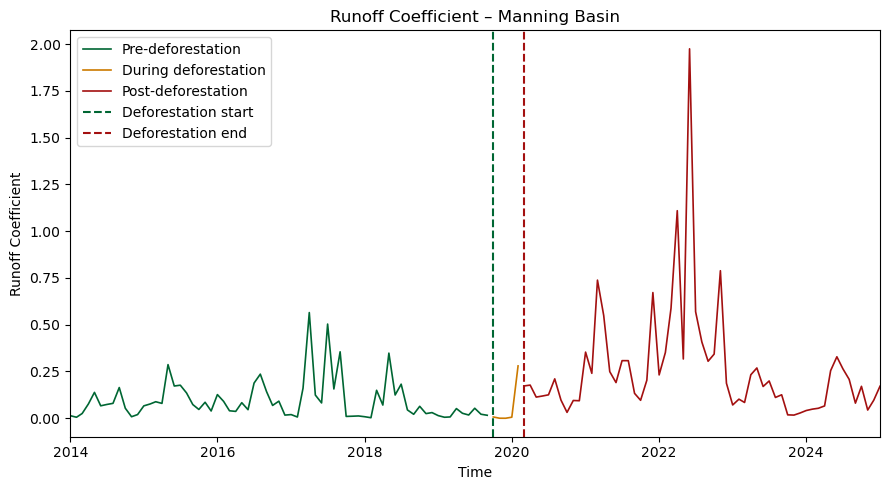


Highest RC values:
                  P_mm      EP_mm        Q_mm        RC
2009-08-01    3.567764  57.699153    7.355252  2.061586
2005-07-01   18.604081  41.875772   38.086205  2.047196
2022-06-01    8.806413  37.253425   17.393717  1.975119
1990-04-01   38.668868  21.031199   56.839974  1.469916
2001-06-01    7.955015  37.882981   10.974335  1.379549
1985-05-01   84.607794  53.298995  103.649158  1.225054
2022-04-01   70.273158  69.127865   77.982387  1.109704
2011-06-01  157.409615  45.663076  155.909620  0.990471
1985-07-01  109.629044  46.509290  104.769795  0.955676
1984-08-01   17.046994  57.732264   16.231792  0.952179


In [4]:

shape_area_manning = 6642 * 1_000_000  # 6642 km2

evap_daily = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap_daily["Date"] = pd.to_datetime(evap_daily["system:index"], format="%Y%m%d")
evap_daily = evap_daily.set_index("Date")[["total_evaporation_sum"]].rename(
    columns={"total_evaporation_sum": "ERA5_Evaporation"})


# convert from m/day to mm/day
evap_daily["ERA5_Evaporation"] = evap_daily["ERA5_Evaporation"].abs() * 1000


precip_daily = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip_daily["Date"] = pd.to_datetime(precip_daily["system:index"], format="%Y%m%d")
precip_daily = precip_daily.set_index("Date")[["total_precipitation_sum"]].rename(
    columns={"total_precipitation_sum": "ERA5_Precipitation"}
)

# convert from m/day to mm/day
precip_daily["ERA5_Precipitation"] = precip_daily["ERA5_Precipitation"] * 1000


Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=";",
    skiprows=36,
    header=0,
    encoding="cp1252",
    index_col=0,
    parse_dates=True
)

Obs.index.name = "Day"
Obs = Obs.rename(columns={" Value": "Q_m3s"})  # note leading space in original column name

# remove missing values
Obs = Obs[Obs["Q_m3s"] != -999]

# convert discharge from m3/s to mm/day
Obs["Q_mm_day"] = Obs["Q_m3s"] * 86400 / shape_area_manning * 1000

Obs = Obs.loc["1981-01-01":"2025-12-31"]


df_daily = pd.concat(
    [
        precip_daily[["ERA5_Precipitation"]],
        evap_daily[["ERA5_Evaporation"]],
        Obs[["Q_mm_day"]]
    ],
    axis=1
).dropna()

df_daily.index = pd.to_datetime(df_daily.index)


df_monthly = pd.DataFrame()
df_monthly["P_mm"] = df_daily["ERA5_Precipitation"].resample("MS").sum()
df_monthly["EP_mm"] = df_daily["ERA5_Evaporation"].resample("MS").sum()
df_monthly["Q_mm"] = df_daily["Q_mm_day"].resample("MS").sum()

df_monthly = df_monthly.dropna()


# Runoff coefficient
df_monthly["RC"] = df_monthly["Q_mm"] / df_monthly["P_mm"]

# optional: remove impossible / unstable values when P is near zero
# you can comment this out if you want to keep everything
df_monthly = df_monthly[df_monthly["P_mm"] > 1]

pre_start = "2014-01-01"
pre_end   = "2019-10-01"

during_start = "2019-10-01"
during_end   = "2020-03-01"

post_start = "2020-03-01"
post_end   = "2025-01-01"

rc_pre = df_monthly[(df_monthly.index >= pre_start) & (df_monthly.index < during_start)].copy()
rc_during = df_monthly[(df_monthly.index >= during_start) & (df_monthly.index < post_start)].copy()
rc_post = df_monthly[(df_monthly.index >= post_start) & (df_monthly.index <= post_end)].copy()


print("Mean RC pre-deforestation/fire period  :", rc_pre["RC"].mean())
print("Mean RC during deforestation/fire period:", rc_during["RC"].mean())
print("Mean RC post-deforestation/fire period :", rc_post["RC"].mean())

plt.figure(figsize=(9, 5))

plt.plot(rc_pre.index, rc_pre["RC"], color="#006633", linewidth=1.2, label="Pre-deforestation")
plt.plot(rc_during.index, rc_during["RC"], color="#cc7a00", linewidth=1.2, label="During deforestation")
plt.plot(rc_post.index, rc_post["RC"], color="#a31010", linewidth=1.2, label="Post-deforestation")

plt.axvline(pd.Timestamp(during_start), linestyle="--", color="#006633", linewidth=1.5, label="Deforestation start")
plt.axvline(pd.Timestamp(post_start), linestyle="--", color="#a31010", linewidth=1.5, label="Deforestation end")

plt.title("Runoff Coefficient – Manning Basin")
plt.xlabel("Time")
plt.ylabel("Runoff Coefficient")
plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.legend()
plt.tight_layout()
plt.show()


print("\nHighest RC values:")
print(df_monthly.sort_values("RC", ascending=False).head(10))


df_monthly.to_csv("./Data/manning_runoff_coefficient_monthly.csv")

Mean discharge pre : 5.607137881465771
Mean discharge post: 25.244156648752924
Difference (post - pre): 19.637018767287152


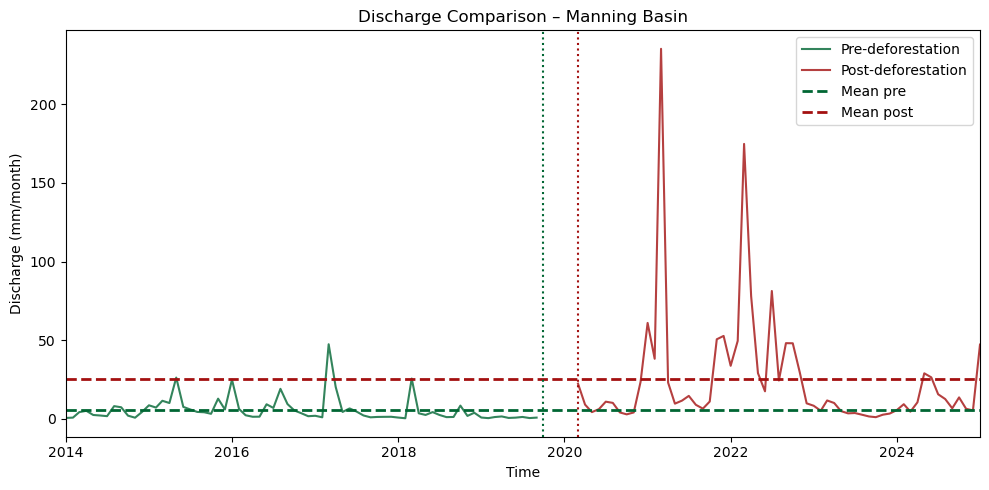

In [4]:
q_pre = df_monthly[(df_monthly.index >= "2014-01-01") & 
                   (df_monthly.index < "2019-10-01")]["Q_mm"]

q_post = df_monthly[(df_monthly.index >= "2020-03-01") & 
                    (df_monthly.index <= "2025-01-01")]["Q_mm"]


mean_pre = q_pre.mean()
mean_post = q_post.mean()

print("Mean discharge pre :", mean_pre)
print("Mean discharge post:", mean_post)
print("Difference (post - pre):", mean_post - mean_pre)

plt.figure(figsize=(10,5))

# Time series
plt.plot(q_pre.index, q_pre, color="#006633", alpha=0.8, label="Pre-deforestation")
plt.plot(q_post.index, q_post, color="#a31010", alpha=0.8, label="Post-deforestation")
# Mean lines
plt.axhline(mean_pre, color="#006633", linestyle="--", linewidth=2, label="Mean pre")
plt.axhline(mean_post, color="#a31010", linestyle="--", linewidth=2, label="Mean post")
# Event lines
plt.axvline(pd.Timestamp("2019-10-01"), linestyle=':', color='#006633')
plt.axvline(pd.Timestamp("2020-03-01"), linestyle=':', color='#a31010')
plt.title("Discharge Comparison – Manning Basin")
plt.xlabel("Time")
plt.ylabel("Discharge (mm/month)")
plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.legend()
plt.tight_layout()
plt.show()

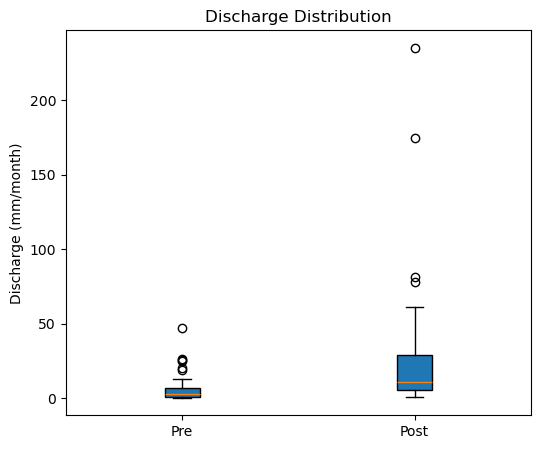

In [5]:
plt.figure(figsize=(6,5))

plt.boxplot([q_pre, q_post],
            labels=["Pre", "Post"],
            patch_artist=True)

plt.title("Discharge Distribution")
plt.ylabel("Discharge (mm/month)")

plt.show()

In [7]:
perc_change = (mean_post - mean_pre) / mean_pre * 100
print("Percentage change:", perc_change, "%")

Percentage change: 350.2146582162129 %


ERA5: increasing trend
  slope per month = 0.2204 mm/month
  p-value = 0.1078

CHIRPS: increasing trend
  slope per month = 0.1792 mm/month
  p-value = 0.1864

IMERG: increasing trend
  slope per month = 0.3306 mm/month
  p-value = 0.0361



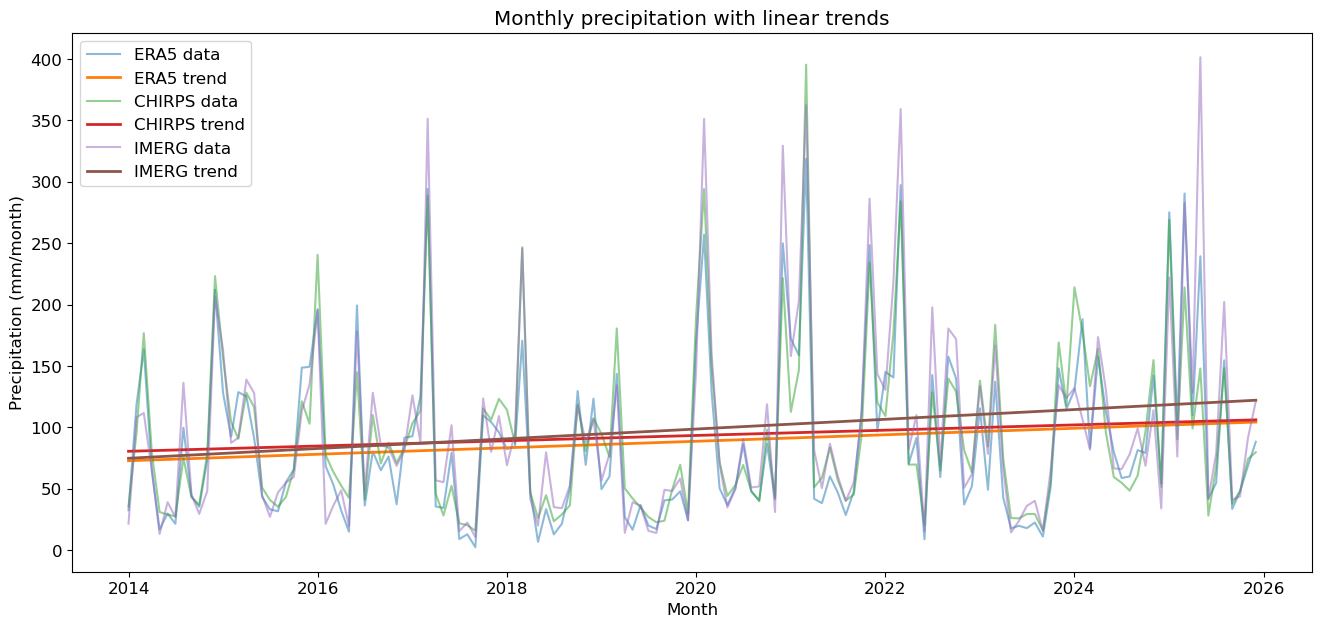

In [19]:

era5P = pd.read_csv('./Data/manning_ERA5_precip_daily.csv')      # m/day
chirps = pd.read_csv('./Data/manning_chirps_precip_daily.csv')   # mm/day
imerg = pd.read_csv('./Data/manning_IMERG_precip_hourly.csv')    # mm/hr


era5P['date'] = pd.to_datetime(era5P['system:index'], format='%Y%m%d')
era5P = era5P.set_index('date')
era5P = era5P.drop(columns=['system:index'])
era5P['total_precipitation_sum'] = era5P['total_precipitation_sum'] * 1000  # m/day -> mm/day
era5P_monthly = era5P.resample('MS').sum()


chirps['date'] = pd.to_datetime(chirps['system:index'], format='%Y%m%d')
chirps = chirps.set_index('date')
chirps = chirps.drop(columns=['system:index'])
chirps_monthly = chirps.resample('MS').sum()

imerg['date'] = pd.to_datetime(imerg['system:index'], format='%Y%m%d%H%M%S')
imerg = imerg.set_index('date')
imerg = imerg.drop(columns=['system:index'])


imerg = imerg.resample('D').sum() / 2
imerg_monthly = imerg.resample('MS').sum()

start_date = '2014-01-01'
end_date = '2025-12-31'

era5P_monthly = era5P_monthly.loc[start_date:end_date]
chirps_monthly = chirps_monthly.loc[start_date:end_date]
imerg_monthly = imerg_monthly.loc[start_date:end_date]

P_df = pd.DataFrame({
    'ERA5': era5P_monthly['total_precipitation_sum'],
    'CHIRPS': chirps_monthly['precipitation'],
    'IMERG': imerg_monthly['precipitation']
})

P_df = P_df.dropna()

plt.figure(figsize=(16, 7))

for col in P_df.columns:
    y = P_df[col].values
    x = np.arange(len(y))

    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    trend_line = intercept + slope * x

    plt.plot(P_df.index, y, label=f'{col} data', alpha=0.5)
    plt.plot(P_df.index, trend_line, linewidth=2, label=f'{col} trend')

    if slope > 0:
        direction = 'increasing trend'
    elif slope < 0:
        direction = 'decreasing trend'
    else:
        direction = 'no trend'

    print(f'{col}: {direction}')
    print(f'  slope per month = {slope:.4f} mm/month')
    print(f'  p-value = {p_value:.4f}')
    print('')

plt.legend()
plt.xlabel('Month')
plt.ylabel('Precipitation (mm/month)')
plt.title('Monthly precipitation with linear trends')
plt.show()

All precipitation datasets show a slight increasing trend over time. However, only the IMERG dataset shows a statistically significant trend (p < 0.05), while ERA5 and CHIRPS do not. This indicates that although precipitation may have increased slightly, the evidence is not consistent across datasets. Because precipitation is the main driver of river discharge, this variability makes it difficult to attribute changes in discharge solely to vegetation loss. Any observed increase in discharge may partly be explained by changes in precipitation. However, we don't use the IMERG data in our model, so we assume no trend in precipitation.